# Amostragem e Pré-processamento da Base

**(v1) 30/04/2026** - Amostragem temporal realizada entre os anos de 2022 e 2026 para evitar o viés pandêmico

In [207]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from unidecode import unidecode

In [3]:
BASE_DIR = Path(__name__).resolve().parent.parent

In [79]:
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Amostragem Temporal

In [15]:
dfs = []

for i in range(2, 7):
    df = pd.read_csv(BASE_DIR / f"data/raw/datatran202{i}.csv",
                    sep=";", encoding="latin1")
    dfs.append(df)

dfs[0].head(5) # Dados de 2022

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,405151,2022-01-01,sábado,01:35:00,PI,316,415,MARCOLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,...,0,1,1,1,3,"-7,43280012","-40,68261908",SPRF-PI,DEL04-PI,UOP03-DEL04-PI
1,405158,2022-01-01,sábado,02:40:00,PR,116,33,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,...,0,0,1,1,2,"-25,114403","-48,8467554",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
2,405172,2022-01-01,sábado,05:22:00,MS,163,393,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,...,0,1,1,1,3,"-21,228445","-54,456296",SPRF-MS,DEL02-MS,UOP01-DEL02-MS
3,405203,2022-01-01,sábado,07:00:00,RJ,101,457,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,...,1,1,0,1,2,"-23,03149804","-44,17715297",SPRF-RJ,DEL03-RJ,UOP03-DEL03-RJ
4,405207,2022-01-01,sábado,09:00:00,MG,40,"508,3",RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,...,0,3,0,0,1,"-19,76061249","-44,1347544",SPRF-MG,DEL02-MG,UOP01-DEL02-MG


In [16]:
df_5y = pd.concat(dfs, axis=0, ignore_index=True)

print(f"Formato dos Dados: {df_5y.shape}")
df_5y.head()

Formato dos Dados: (301532, 30)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,405151.0,2022-01-01,sábado,01:35:00,PI,316,415,MARCOLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,...,0,1,1,1,3,"-7,43280012","-40,68261908",SPRF-PI,DEL04-PI,UOP03-DEL04-PI
1,405158.0,2022-01-01,sábado,02:40:00,PR,116,33,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,...,0,0,1,1,2,"-25,114403","-48,8467554",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
2,405172.0,2022-01-01,sábado,05:22:00,MS,163,393,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,...,0,1,1,1,3,"-21,228445","-54,456296",SPRF-MS,DEL02-MS,UOP01-DEL02-MS
3,405203.0,2022-01-01,sábado,07:00:00,RJ,101,457,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,...,1,1,0,1,2,"-23,03149804","-44,17715297",SPRF-RJ,DEL03-RJ,UOP03-DEL03-RJ
4,405207.0,2022-01-01,sábado,09:00:00,MG,40,"508,3",RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,...,0,3,0,0,1,"-19,76061249","-44,1347544",SPRF-MG,DEL02-MG,UOP01-DEL02-MG


In [17]:
output_path = BASE_DIR / "data/raw/datatran_merged_2022_2026.csv"
df_5y.to_csv(output_path, sep=";", encoding="latin1")
print("Dados mesclados salvos!")

Dados mesclados salvos!


## Análise Inicial

In [156]:
df_raw = pd.read_csv(BASE_DIR / "data/raw/datatran_merged_2022_2026.csv", 
                     encoding="latin1", sep=";", index_col=0, low_memory=False)

df_raw.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,405151.0,2022-01-01,sábado,01:35:00,PI,316,415,MARCOLANDIA,Ingestão de álcool pelo condutor,Colisão traseira,NaN,Plena Noite,Decrescente,Nublado,Simples,Reta,Sim,3,0,1,0,1,1,1,3,"-7,43280012","-40,68261908",SPRF-PI,DEL04-PI,UOP03-DEL04-PI
1,405158.0,2022-01-01,sábado,02:40:00,PR,116,33,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,Com Vítimas Fatais,Pleno dia,Decrescente,Nublado,Dupla,Curva,Não,3,1,1,0,0,1,1,2,"-25,114403","-48,8467554",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
2,405172.0,2022-01-01,sábado,05:22:00,MS,163,393,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,Com Vítimas Feridas,Amanhecer,Decrescente,Céu Claro,Simples,Aclive,Não,3,0,1,0,1,1,1,3,"-21,228445","-54,456296",SPRF-MS,DEL02-MS,UOP01-DEL02-MS
3,405203.0,2022-01-01,sábado,07:00:00,RJ,101,457,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva,Sim,2,0,0,1,1,0,1,2,"-23,03149804","-44,17715297",SPRF-RJ,DEL03-RJ,UOP03-DEL03-RJ
4,405207.0,2022-01-01,sábado,09:00:00,MG,40,"508,3",RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,Sem Vítimas,Pleno dia,Decrescente,Chuva,Dupla,Reta,Sim,3,0,0,0,3,0,0,1,"-19,76061249","-44,1347544",SPRF-MG,DEL02-MG,UOP01-DEL02-MG


In [21]:
df_raw.shape

(301532, 30)

In [22]:
def diagnostic_from_database(df: pd.DataFrame):

    print("======= DIAGNÓSTICO INICIAL AUTOMATIZADO =======\n\n")

    rows, cols = df.shape
    print(f"Dimensões dos Dados: {rows} linhas, {cols} colunas")
    print(f"Linhas duplicadas: {df.duplicated().sum()}\n")

    columns_dtypes = df.dtypes
    missing_values = df.isnull().sum()
    uniques = df.nunique()

    diagnostic_map = {
        "Tipos de Dados": columns_dtypes,
        "Valores Ausentes": missing_values,
        "Cardinalidade": uniques
    }

    display(pd.DataFrame(diagnostic_map))

In [23]:
diagnostic_from_database(df_raw)

======= DIAGNÓSTICO INICIAL AUTOMATIZADO =======


Dimensões dos Dados: 301532 linhas, 30 colunas
Linhas duplicadas: 0



,Tipos de Dados,Valores Ausentes,Cardinalidade
id,float64,0,301532
data_inversa,str,0,1581
dia_semana,str,0,7
horario,str,0,1440
uf,str,0,27
br,int64,0,125
km,str,0,9412
municipio,str,0,2050
causa_acidente,str,0,76
tipo_acidente,str,0,17


### Colunas `regional`, `delegacia`, `uop`

Colunas com valores nulos, mas que não acrescentam muito para análise, visto que 

### Coluna `classificacao_acidente`

Coluna tem 5 valores nulos, que correspondem a menos de 0.002% dos dados e, portanto, podem ser dropados da base

In [107]:
df_raw["classificacao_acidente"].unique()

<StringArray>
[nan, 'Com Vítimas Fatais', 'Com Vítimas Feridas', 'Sem Vítimas']
Length: 4, dtype: str

In [56]:
porc_classficacao_nan = df_raw["classificacao_acidente"].isna().sum() / df_raw.shape[0] * 100

print(f"% de Nulos em `classificacao_acidente` : {porc_classficacao_nan:.5f} %")

% de Nulos em `classificacao_acidente` : 0.00166 %


### Coluna `km`

Coluna estava como tipo `str`, com separador de casas decimais sendo vírgula. Fazendo a conversão para numérico e vendo o `describe`.

- Não há valor distoante máximo de quilometragem, visto que a [maior RF (BR 116) tem 4 713,64 km de extensão](https://pt.wikipedia.org/wiki/BR-116)

In [59]:
df_raw["km"].unique()

<StringArray>
[  '415',    '33',   '393',   '457', '508,3',   '8,7', '452,2',  '80,1',
 '139,7', '415,4',
 ...
 '784,7', '803,3', '948,1', '822,7',  '1241', '824,2', '883,4', '887,1',
 '933,7', '971,8']
Length: 9412, dtype: str

In [63]:
df_raw[df_raw["km"].str.len() > 5]["km"].unique()

<StringArray>
['1024,3', '1069,9', '1063,3', '1040,3', '1118,8', '1110,2', '1034,1',
 '1065,8', '1041,7', '1032,1', '1111,5', '1013,4', '1110,9', '1036,9',
 '1109,9', '1056,4', '1051,1', '1041,5', '1010,5', '1190,8', '1169,8',
 '1048,3', '1022,9', '1103,7', '1017,8', '1026,9', '1044,8', '1061,6',
 '1073,6', '1071,5']
Length: 30, dtype: str

In [176]:
df_raw["km"] = df_raw["km"].str.replace(",", ".", regex=False)
df_raw["km"] = pd.to_numeric(df_raw["km"])

df_raw["km"].describe()

count    301532.000000
mean        259.281586
std         226.901626
min           0.000000
25%          77.000000
50%         193.000000
75%         407.000000
max        1470.000000
Name: km, dtype: float64

In [86]:
df_raw[df_raw["km"] == df_raw["km"].max()]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
194362,636703.0,2024-09-16,segunda-feira,10:00:00,PA,230,1470.0,JACAREACANGA,Demais falhas na via,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Simples,Curva,Não,1,0,1,0,0,0,1,1,-5.75874258,-57.601844,SPRF-PA,DEL05-PA,UOP02-DEL05-PA


In [89]:
pd.set_option("display.max_rows", 10)
df_raw[df_raw["km"] == df_raw["km"].min()]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
10,405256.0,2022-01-01,sábado,09:50:00,MT,70,0.0,PONTAL DO ARAGUAIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Pleno dia,Crescente,Chuva,Simples,Interseção de Vias;Reta;Ponte,Sim,7,0,2,0,4,1,2,6,"-15,9106","-52,2614",SPRF-MT,DEL07-MT,UOP01-DEL07-MT
466,408545.0,2022-01-14,sexta-feira,09:20:00,SP,381,0.0,VARGEM,Ausência de reação do condutor,Engavetamento,Sem Vítimas,Pleno dia,Crescente,Chuva,Dupla,Reta;Aclive,Não,6,0,0,0,4,4,0,8,"-22,878674","-46,372143",SPRF-SP,DEL03-SP,UOP01-DEL03-SP
490,408663.0,2022-01-14,sexta-feira,20:30:00,BA,0,0.0,BARREIRAS,Entrada inopinada do pedestre,Atropelamento de Pedestre,Com Vítimas Fatais,Plena Noite,Não Informado,Céu Claro,Simples,Reta,Não,3,1,0,0,1,2,0,4,"-12,1376959","-44,921313",SPRF-BA,DEL10-BA,UOP01-DEL10-BA
597,409451.0,2022-01-17,segunda-feira,13:00:00,MS,0,0.0,BATAGUASSU,Problema com o freio,Incêndio,Sem Vítimas,Pleno dia,Não Informado,Sol,Simples,Reta,Não,2,0,0,0,1,2,0,3,"-21,72532","-52,256202",SPRF-MS,DEL02-MS,UOP04-DEL02-MS
1142,411812.0,2022-01-29,sábado,15:00:00,RO,0,0.0,ARIQUEMES,Problema com o freio,Colisão com objeto,Sem Vítimas,Pleno dia,Não Informado,Céu Claro,Simples,Declive,Sim,2,0,0,0,1,1,0,2,"-9,93398403","-63,05522959",SPRF-RO,DEL03-RO,UOP01-DEL03-RO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301133,768152.0,2026-04-09,quinta-feira,18:40:00,PA,0,0.0,ANAPU,Reação tardia ou ineficiente do condutor,Colisão com objeto,Sem Vítimas,Anoitecer,Não Informado,Chuva,Simples,Declive;Reta,Não,4,0,0,0,4,0,0,1,"-2,92694734","-51,66599751",SPRF-PA,DEL04-PA,UOP01-DEL04-PA
301207,768277.0,2026-04-09,quinta-feira,10:40:00,DF,70,0.0,BRASILIA,Reação tardia ou ineficiente do condutor,Colisão com objeto,Sem Vítimas,Pleno dia,Crescente,Nublado,Dupla,Reta,Não,3,0,0,0,3,0,0,3,"-15,78418014","-48,23243737",SPRF-DF,DEL03-DF,UOP02-DEL03-DF
301441,768716.0,2026-04-09,quinta-feira,08:30:00,RJ,0,0.0,RIO DE JANEIRO,Ultrapassagem Indevida,Colisão lateral mesmo sentido,Com Vítimas Feridas,Pleno dia,Não Informado,Céu Claro,Dupla,Reta,Sim,3,0,2,0,1,0,2,2,"-22,93144125","-43,20890343",SPRF-RJ,DEL02-RJ,UOP02-DEL02-RJ
301451,768956.0,2026-04-27,segunda-feira,17:00:00,RO,421,0.0,ARIQUEMES,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Simples,Interseção de Vias;Reta,Não,2,0,1,0,0,1,1,2,"-9,916072","-63,055972",SPRF-RO,DEL03-RO,UOP01-DEL03-RO


In [116]:
porc_km_0 = df_raw[df_raw["km"] == df_raw["km"].min()].shape[0] / df_raw.shape[0] * 100

print(f"% de KM preenchido com 0 : {porc_km_0:.5f} %")

% de KM preenchido com 0 : 0.47590 %


### Coluna `br`

In [99]:
np.sort(df_raw["br"].unique())

array([  0,  10,  20,  30,  40,  50,  60,  70,  80, 101, 104, 110, 116,
       122, 135, 146, 153, 155, 156, 158, 163, 174, 210, 222, 226, 230,
       232, 235, 242, 251, 259, 262, 265, 267, 272, 277, 280, 282, 285,
       287, 290, 293, 304, 307, 308, 316, 317, 319, 324, 330, 342, 343,
       349, 352, 354, 356, 359, 361, 363, 364, 365, 367, 369, 373, 376,
       381, 386, 392, 393, 401, 402, 403, 405, 406, 407, 408, 410, 412,
       414, 415, 416, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427,
       428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 447, 448, 452,
       459, 463, 465, 466, 467, 468, 469, 470, 471, 472, 476, 480, 482,
       484, 485, 487, 488, 493, 494, 495, 498])

In [101]:
acidentes_br_0 = (df_raw["br"] == 0).sum()

print(f"Total de dados com BR 0: {acidentes_br_0}")

Total de dados com BR 0: 756


### Colunas numéricas de pessoas e veículos envolvidos

In [25]:
pd.set_option("display.max_columns", None)
df_raw.describe()

,id,br,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos
count,301532.000000,301532.000000,301532.000000,301532.000000,301532.000000,301532.000000,301532.000000,301532.000000,301532.000000,301532.000000
mean,594424.580147,209.837291,2.596408,0.083537,0.873038,0.278286,1.050751,0.398170,1.151324,1.990482
std,101236.627468,129.434602,2.234036,0.345159,1.090659,0.622248,1.767427,0.852789,1.214018,1.127652
min,405147.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,509731.750000,101.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,593327.500000,158.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000
75%,686764.250000,324.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000
max,772176.000000,498.000000,95.000000,37.000000,83.000000,35.000000,85.000000,88.000000,84.000000,131.000000


Nenhuma anormalidade na distribuição dos dados numéricos

In [72]:
feridos_corretos = (df_raw["feridos"] == df_raw["feridos_leves"] + df_raw["feridos_graves"]).sum()
pessoas_corretos = (df_raw["pessoas"] == df_raw["mortos"] + df_raw["feridos"] + df_raw["ilesos"] + df_raw["ignorados"]).sum()

print(f"FERIDOS = FERIDOS LEVES + FERIDOS GRAVES? {feridos_corretos == df_raw.shape[0]}\nErro: {df_raw.shape[0] - feridos_corretos}\n")
print(f"PESSOAS = MORTOS + FERIDOS + ILESOS + IGNORADOS? {pessoas_corretos == df_raw.shape[0]}\nErro: {df_raw.shape[0] - pessoas_corretos}\n")

FERIDOS = FERIDOS LEVES + FERIDOS GRAVES? True
Erro: 0

PESSOAS = MORTOS + FERIDOS + ILESOS + IGNORADOS? False
Erro: 16253



#### Observações

Existem **16.253 pessoas sem classificação envolvidas em ocorrências**. Podem ser pessoas que fugiram, não quiseram atendimento ou simplesmente não foram identificados na ocorrência no momento do acidente.

- Possibilidade de criação de nova coluna: `sem_classificacao`
- Existe correlação com situações de acidentes graves?

### Coluna `tracado_via`

Coluna possui 1199 tipos únicos, mas que são na verdade múltiplos tipos separados por ";"

In [43]:
df_raw["tracado_via"].unique()

<StringArray>
[                                                        'Reta',
                                                        'Curva',
                                                       'Aclive',
                                                      'Declive',
                                                'Declive;Curva',
                                'Interseção de Vias;Reta;Ponte',
                                                        'Ponte',
                                           'Interseção de Vias',
                                                'Curva;Declive',
                                                    'Rotatória',
 ...
                   'Viaduto;Curva;Rotatória;Interseção de Vias',
                        'Reta;Em Obras;Ponte;Desvio Temporário',
              'Em Obras;Viaduto;Declive;Desvio Temporário;Reta',
                'Retorno Regulamentado;Desvio Temporário;Curva',
                      'Em Obras;Curva;Aclive;Desvio Temporário',
      

In [204]:
tracado_via_unique_str = ";".join(df_raw["tracado_via"].unique())

In [205]:
set(tracado_via_unique_str.split(";"))

{'Aclive',
 'Curva',
 'Declive',
 'Desvio Temporário',
 'Em Obras',
 'Interseção de Vias',
 'Ponte',
 'Reta',
 'Retorno Regulamentado',
 'Rotatória',
 'Túnel',
 'Viaduto'}

#### Observações

Existem apenas 12 tipos únicos dentre as múltiplas classificações de `tracado_via`. 

Possibilidade de feature engeneering: 

- One-Hot Enconding a partir do split dos valores de `tracado_via`, criando 12 novas colunas binárias

### Coluna `tipo_acidente`

In [73]:
df_raw["tipo_acidente"].unique()

<StringArray>
[              'Colisão traseira',                     'Tombamento',
                'Colisão frontal',      'Saída de leito carroçável',
             'Colisão com objeto',  'Colisão lateral mesmo sentido',
                  'Engavetamento', 'Colisão lateral sentido oposto',
            'Colisão transversal',                    'Capotamento',
   'Queda de ocupante de veículo',                       'Incêndio',
          'Derramamento de carga',      'Atropelamento de Pedestre',
               'Eventos atípicos',        'Atropelamento de Animal',
   'Sinistro pessoal de trânsito']
Length: 17, dtype: str

### Coluna `causa_acidente`

In [46]:
df_raw["causa_acidente"].unique()

<StringArray>
[                                            'Ingestão de álcool pelo condutor',
                     'Condutor deixou de manter distância do veículo da frente',
                                     'Reação tardia ou ineficiente do condutor',
                                            'Acumulo de água sobre o pavimento',
                                                       'Mal súbito do condutor',
                                                                        'Chuva',
                                               'Ausência de reação do condutor',
                                                  'Manobra de mudança de faixa',
                                                           'Pista Escorregadia',
                                                      'Ausência de sinalização',
                                                            'Condutor Dormindo',
                                                      'Velocidade Incompatível',
              

In [122]:
pd.set_option("display.max_rows", None)
df_raw["causa_acidente"].value_counts(sort=True, ascending=False)[:15]

causa_acidente
Reação tardia ou ineficiente do condutor                     43468
Ausência de reação do condutor                               42716
Acessar a via sem observar a presença dos outros veículos    28240
Velocidade Incompatível                                      18988
Condutor deixou de manter distância do veículo da frente     18868
Manobra de mudança de faixa                                  16966
Ingestão de álcool pelo condutor                             16584
Demais falhas mecânicas ou elétricas                         13483
Transitar na contramão                                       10119
Condutor Dormindo                                             9162
Ultrapassagem Indevida                                        7266
Animais na Pista                                              5790
Desrespeitar a preferência no cruzamento                      5780
Avarias e/ou desgaste excessivo no pneu                       5288
Trafegar com motocicleta (ou similar) entre as 

In [123]:
pd.set_option("display.max_rows", None)
df_raw["causa_acidente"].value_counts(sort=True, ascending=True)[:15]

causa_acidente
Sistema de drenagem ineficiente                            9
Obstrução Via tentativa Assalto                           10
Sinalização encoberta                                     18
Faróis desregulados                                       31
Redutor de velocidade em desacordo                        34
Semáforo com defeito                                      35
Transitar na calçada                                      47
Restrição de visibilidade em curvas verticais             47
Faixas de trânsito com largura insuficiente               51
Modificação proibida                                      52
Deixar de acionar o farol da motocicleta (ou similar)     56
Participar de racha                                       72
Restrição de visibilidade em curvas horizontais           93
Pista em desnível                                        101
Declive acentuado                                        102
Name: count, dtype: int64

#### AGURPAMENTO SEMÂNTICO DE `causa_acidente`

| Grupo Semântico                    | Subcategorias | O que representa                                           |
| ---------------------------------- | ------------- | ---------------------------------------------------------- |
| **falha\_atencao\_reacao**         | 8             | Distração, sono, reação tardia, celular, freio brusco      |
| **infracao\_comportamento\_risco** | 17            | Álcool, velocidade, contramão, ultrapassagem, racha        | 
| **falha\_mecanica\_veiculo**       | 5             | Pneu, freio, suspensão, faróis                             | 
| **infraestrutura\_sinalizacao**    | 20            | Sinalização, iluminação, pista esburacada, obras, drenagem | 
| **condicao\_ambiental\_pavimento** | 13            | Chuva, neblina, animais, pista escorregadia, curva/declive |
| **pedestre**                       | 7             | Atropelamento, travessia fora da faixa, álcool do pedestre |
| **condicao\_saude\_condutor**      | 3             | Mal súbito, transtorno mental, suicídio                    | 
| **acesso\_obstrucao**              | 3             | Acesso irregular, carga mal acondicionada, assalto         | 

In [192]:
MAPEAMENTO_CAUSA = {
    # falha_atencao_reacao
    'Reação tardia ou ineficiente do condutor': 'falha_atencao_reacao',
    'Ausência de reação do condutor': 'falha_atencao_reacao',
    'Condutor deixou de manter distância do veículo da frente': 'falha_atencao_reacao',
    'Acessar a via sem observar a presença dos outros veículos': 'falha_atencao_reacao',
    'Manobra de mudança de faixa': 'falha_atencao_reacao',
    'Condutor Dormindo': 'falha_atencao_reacao',
    'Condutor usando celular': 'falha_atencao_reacao',
    'Frear bruscamente': 'falha_atencao_reacao',
    
    # infracao_comportamento_risco
    'Velocidade Incompatível': 'infracao_comportamento_risco',
    'Ingestão de álcool pelo condutor': 'infracao_comportamento_risco',
    'Ingestão de substâncias psicoativas pelo condutor': 'infracao_comportamento_risco',
    'Transitar na contramão': 'infracao_comportamento_risco',
    'Ultrapassagem Indevida': 'infracao_comportamento_risco',
    'Trafegar com motocicleta (ou similar) entre as faixas': 'infracao_comportamento_risco',
    'Desrespeitar a preferência no cruzamento': 'infracao_comportamento_risco',
    'Conversão proibida': 'infracao_comportamento_risco',
    'Retorno proibido': 'infracao_comportamento_risco',
    'Participar de racha': 'infracao_comportamento_risco',
    'Estacionar ou parar em local proibido': 'infracao_comportamento_risco',
    'Transitar no acostamento': 'infracao_comportamento_risco',
    'Transitar no Acostamento': 'infracao_comportamento_risco',
    'Transitar na calçada': 'infracao_comportamento_risco',
    'Modificação proibida': 'infracao_comportamento_risco',
    'Deixar de acionar o farol da motocicleta (ou similar)': 'infracao_comportamento_risco',
    'Condutor desrespeitou a iluminação vermelha do semáforo': 'infracao_comportamento_risco',
    
    # falha_mecanica_veiculo
    'Demais falhas mecânicas ou elétricas': 'falha_mecanica_veiculo',
    'Avarias e/ou desgaste excessivo no pneu': 'falha_mecanica_veiculo',
    'Problema com o freio': 'falha_mecanica_veiculo',
    'Problema na suspensão': 'falha_mecanica_veiculo',
    'Faróis desregulados': 'falha_mecanica_veiculo',
    
    # infraestrutura_sinalizacao
    'Ausência de sinalização': 'infraestrutura_sinalizacao',
    'Sinalização mal posicionada': 'infraestrutura_sinalizacao',
    'Sinalização encoberta': 'infraestrutura_sinalizacao',
    'Deficiência do Sistema de Iluminação/Sinalização': 'infraestrutura_sinalizacao',
    'Iluminação deficiente': 'infraestrutura_sinalizacao',
    'Semáforo com defeito': 'infraestrutura_sinalizacao',
    'Redutor de velocidade em desacordo': 'infraestrutura_sinalizacao',
    'Pista esburacada': 'infraestrutura_sinalizacao',
    'Pista em desnível': 'infraestrutura_sinalizacao',
    'Afundamento ou ondulação no pavimento': 'infraestrutura_sinalizacao',
    'Acostamento em desnível': 'infraestrutura_sinalizacao',
    'Faixas de trânsito com largura insuficiente': 'infraestrutura_sinalizacao',
    'Falta de acostamento': 'infraestrutura_sinalizacao',
    'Falta de elemento de contenção que evite a saída do leito carroçável': 'infraestrutura_sinalizacao',
    'Obras na pista': 'infraestrutura_sinalizacao',
    'Desvio temporário': 'infraestrutura_sinalizacao',
    'Sistema de drenagem ineficiente': 'infraestrutura_sinalizacao',
    'Objeto estático sobre o leito carroçável': 'infraestrutura_sinalizacao',
    'Obstrução na via': 'infraestrutura_sinalizacao',
    'Demais falhas na via': 'infraestrutura_sinalizacao',
    
    # condicao_ambiental_pavimento
    'Chuva': 'condicao_ambiental_pavimento',
    'Neblina': 'condicao_ambiental_pavimento',
    'Fumaça': 'condicao_ambiental_pavimento',
    'Pista Escorregadia': 'condicao_ambiental_pavimento',
    'Acumulo de água sobre o pavimento': 'condicao_ambiental_pavimento',
    'Acumulo de óleo sobre o pavimento': 'condicao_ambiental_pavimento',
    'Acumulo de areia ou detritos sobre o pavimento': 'condicao_ambiental_pavimento',
    'Animais na Pista': 'condicao_ambiental_pavimento',
    'Demais Fenômenos da natureza': 'condicao_ambiental_pavimento',
    'Curva acentuada': 'condicao_ambiental_pavimento',
    'Declive acentuado': 'condicao_ambiental_pavimento',
    'Restrição de visibilidade em curvas horizontais': 'condicao_ambiental_pavimento',
    'Restrição de visibilidade em curvas verticais': 'condicao_ambiental_pavimento',
    
    # pedestre
    'Pedestre cruzava a pista fora da faixa': 'pedestre',
    'Pedestre andava na pista': 'pedestre',
    'Entrada inopinada do pedestre': 'pedestre',
    'Área urbana sem a presença de local apropriado para a travessia de pedestres': 'pedestre',
    'Ingestão de álcool e/ou substâncias psicoativas pelo pedestre': 'pedestre',
    'Ingestão de álcool ou de substâncias psicoativas pelo pedestre': 'pedestre',
    'Pedestre - Ingestão de álcool/ substâncias psicoativas': 'pedestre',
    
    # condicao_saude_condutor
    'Mal súbito do condutor': 'condicao_saude_condutor',
    'Transtornos Mentais (exceto suicidio)': 'condicao_saude_condutor',
    'Suicídio (presumido)': 'condicao_saude_condutor',
    
    # acesso_obstrucao
    'Acesso irregular': 'acesso_obstrucao',
    'Carga excessiva e/ou mal acondicionada': 'acesso_obstrucao',
    'Obstrução Via tentativa Assalto': 'acesso_obstrucao',
}

### Demais Colunas Categóricas

In [75]:
cat_columns = ["fase_dia", "sentido_via", "condicao_metereologica", "tipo_pista", "uso_solo", "dia_semana"]

for col in cat_columns:
    print(f"COLUNA: `{col}`")
    print(df[col].unique())
    print()

COLUNA: `fase_dia`
<StringArray>
['Amanhecer', 'Pleno dia', 'Plena Noite', 'Anoitecer']
Length: 4, dtype: str

COLUNA: `sentido_via`
<StringArray>
['Crescente', 'Decrescente', 'Não Informado']
Length: 3, dtype: str

COLUNA: `condicao_metereologica`
<StringArray>
[       'Céu Claro',          'Nublado',              'Sol',
            'Chuva',         'Ignorado',   'Garoa/Chuvisco',
 'Nevoeiro/Neblina',            'Vento',             'Neve']
Length: 9, dtype: str

COLUNA: `tipo_pista`
<StringArray>
['Simples', 'Dupla', 'Múltipla']
Length: 3, dtype: str

COLUNA: `uso_solo`
<StringArray>
['Não', 'Sim']
Length: 2, dtype: str

COLUNA: `dia_semana`
<StringArray>
[ 'quinta-feira',   'sexta-feira',        'sábado',       'domingo',
 'segunda-feira',   'terça-feira',  'quarta-feira']
Length: 7, dtype: str



sentido_via
Crescente        161970
Decrescente      138806
Não Informado       756
Name: count, dtype: int64


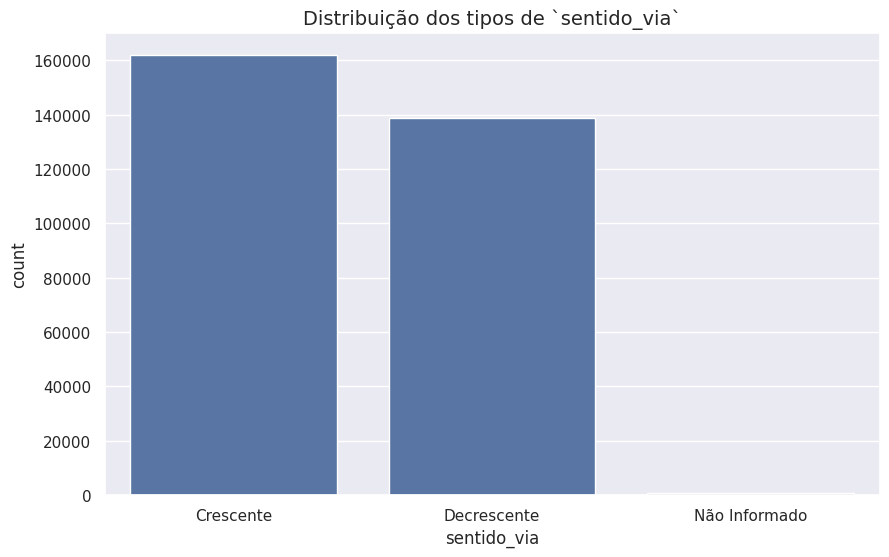

In [108]:
sentido_via_value_counts = df_raw["sentido_via"].value_counts()

print(sentido_via_value_counts)

sns.barplot(sentido_via_value_counts)
plt.title("Distribuição dos tipos de `sentido_via`")
plt.show()

condicao_metereologica
Céu Claro           188941
Nublado              47220
Chuva                30499
Sol                  17126
Garoa/Chuvisco       10816
Ignorado              3965
Nevoeiro/Neblina      2481
Vento                  469
Granizo                  9
Neve                     6
Name: count, dtype: int64


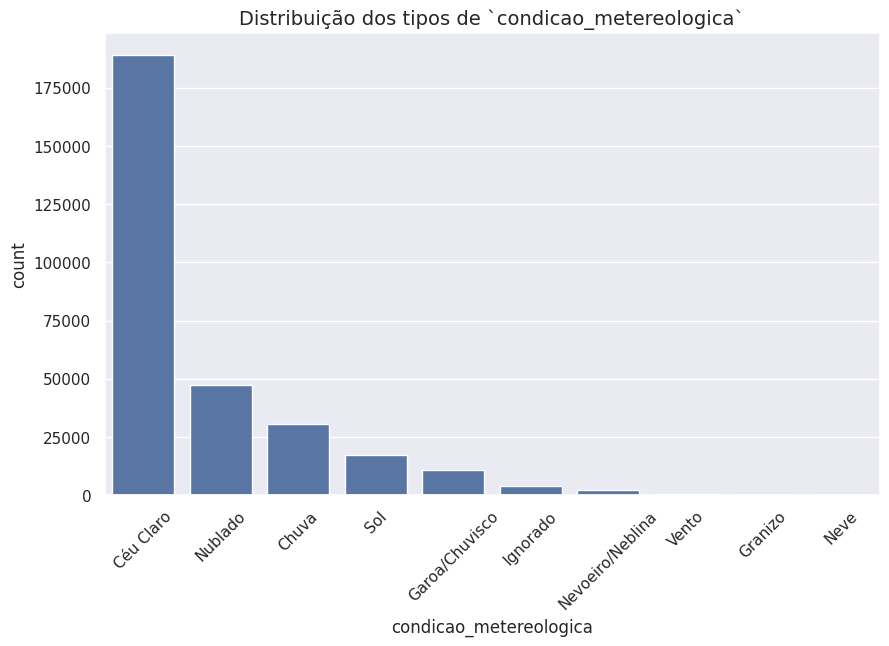

In [178]:
sentido_via_value_counts = df_raw["condicao_metereologica"].value_counts()

print(sentido_via_value_counts)

sns.barplot(sentido_via_value_counts)
plt.title("Distribuição dos tipos de `condicao_metereologica`")
plt.xticks(rotation=45)
plt.show()

### Colunas `sentido_via` e `br`

In [113]:
sem_sentido_via_br_0 = df_raw[(df_raw["sentido_via"] == "Não Informado") & (df_raw["br"] == 0)].shape[0]

print(f"DADO SEM INFORMAÇÃO DE SENTIDO DA VIA E COM BR PREENCHIDA COM 0: {sem_sentido_via_br_0}")

DADO SEM INFORMAÇÃO DE SENTIDO DA VIA E COM BR PREENCHIDA COM 0: 756


### Colunas `km` e `br`

In [177]:
km_0_br_0 = df_raw[(df_raw["km"] == 0) & (df_raw["br"] == 0)].shape[0]

print(f"DADO COM KM PREENCHIDO COM 0 E COM BR PREENCHIDA COM 0: {km_0_br_0}")

DADO COM KM PREENCHIDO COM 0 E COM BR PREENCHIDA COM 0: 756


### Colunas `data_inversa` e `horario`

- Juntando as colunas e convertendo em `Datetime`, não surge nenhum valor nulo
- A intervalo de anos bate com o recorte temporal, sem nenhum outlier nesse sentido
- Todos os valores em `dia_semana` estão corretos em relação a data em `data_inversa`

In [157]:
data_hora = pd.to_datetime(df_raw['data_inversa'] + ' ' + df_raw['horario'], errors='coerce')

n_invalidos = data_hora.isna().sum()
print(f"Datas/horas inválidas: {n_invalidos} ({n_invalidos/len(df_raw)*100:.3f}%)")

Datas/horas inválidas: 0 (0.000%)


In [158]:
print(data_hora.dt.year.value_counts().sort_index())

2022    64606
2023    67766
2024    73156
2025    72529
2026    23475
Name: count, dtype: int64


In [175]:
map_dia_semana = {"segunda-feira": 1, "terça-feira": 2, "quarta-feira": 3,
                  "quinta-feira": 4, "sexta-feira": 5, "sábado": 6, "domingo": 7}

# dt.weekday começa em 0 e pela segunda-feira
dia_semana_correto = (data_hora.dt.weekday + 1 == df_raw["dia_semana"].map(map_dia_semana)).sum() / len(df_raw) * 100

print(f"% de valores em `dia_semana` CORRETOS em relação a data: {dia_semana_correto} %")

% de valores em `dia_semana` CORRETOS em relação a data: 100.0 %


### Colunas `latitude` e `longitude`

- Convertendo de `str` para numérico, valores seguem corretos
- Apenas 1 caso fora do dos pontos extremos do país [definidos pelo IBGE](https://brasilemsintese.ibge.gov.br/territorio/dados-geograficos.html), mas se trata do arquipélago de Fernando de Noronha, então válido

In [136]:
display(df_raw["latitude"])
print()
display(df_raw["longitude"])

0          -7,43280012
1           -25,114403
2           -21,228445
3         -23,03149804
4         -19,76061249
              ...     
301527    -25,43041231
301528    -23,03117312
301529    -14,26699298
301530      -20,007164
301531       -18,68165
Name: latitude, Length: 301532, dtype: str

0         -40,68261908
1          -48,8467554
2           -54,456296
3         -44,17715297
4          -44,1347544
              ...     
301527    -49,34734432
301528    -44,13053514
301529    -39,32657719
301530      -44,215484
301531      -46,565802
Name: longitude, Length: 301532, dtype: str

In [181]:
df_raw["latitude"] = pd.to_numeric(df_raw["latitude"].str.replace(",", "."))
df_raw["longitude"] = pd.to_numeric(df_raw["longitude"].str.replace(",", "."))

In [185]:
n_zeros = ((df_raw['latitude'] == 0) & (df_raw['longitude'] == 0)).sum()
print(f"Lat/Lon = 0,0: {n_zeros:,} ({n_zeros/len(df_raw)*100:.5f}%)")

Lat/Lon = 0,0: 0 (0.00000%)


In [184]:
mask_brasil = (
        (df_raw["latitude"] >= -34) & (df_raw["latitude"] <= 5) &
        (df_raw["longitude"] >= -74) & (df_raw["longitude"] <= -34)
    )
n_fora = (~mask_brasil).sum()
print(f"Fora do Brasil: {n_fora:,} ({n_fora/len(df_raw)*100:.5f}%)")

Fora do Brasil: 1 (0.00033%)


In [147]:
df_raw[~mask_brasil]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
183341,620583.0,2024-08-11,domingo,18:30:00,PE,363,1.5,FERNANDO DE NORONHA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Simples,Reta,Sim,3,0,2,0,1,0,2,2,-3.841072,-32.406822,SPRF-PE,DEL01-PE,UOP01-DEL01-PE


### Conclusões

## Pré-Processamento dos Dados

In [215]:
def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    """Limpa a base de dados corrigindo a tipagem e  removendo colunas irrelevantes,
    com valores ausentes e inconsistente.

    :param df: Dataframe com dados brutos.
    :type df: pd.DataFrame
    :return: Dataframe com dados limpos.
    :rtype: pd.DataFrame
    """
    df_clean = df.copy()

    # Remove colunas irrelevantes
    columns_to_remove = ["id", "regional", "delegacia", "uop"]
    df_clean = df_clean.drop(columns=columns_to_remove)
    
    # Remove valores nulos (5 casos de `classificacao_acidente`)
    df_clean = df_clean.dropna()

    # Converte colunas para o tipo correto (`km` e `latitude`, `longitude`)
    df_clean["km"] = pd.to_numeric(df_clean["km"].str.replace(",", "."))
    df_clean["latitude"] = pd.to_numeric(df_clean["latitude"].str.replace(",", "."))
    df_clean["longitude"] = pd.to_numeric(df_clean["longitude"].str.replace(",", "."))

    # Remove valores inconsistentes (756 onde `km`, `sentido_via` e `br` invalidos, 679 onde `km` é 0)
    df_clean = df_clean[df_clean["km"] > 0]

    # correcao do nome da coluna `condicao_metereologica` -> `condicao_meteorologica`
    df_clean = df_clean.rename(columns={"condicao_metereologica": "condicao_meteorologica"})

    return df_clean

### Engenharia de Features

In [198]:
UF_PARA_REGIAO = {
        'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
        'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 
        'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
        'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
        'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
        'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
    }

In [216]:
def one_hot_encoding_tracado_via(df: pd.DataFrame):

    tracado_via_uniques = set(";".join(df["tracado_via"].unique()).split(";"))

    for tipo in tracado_via_uniques:
        tipo = unidecode(tipo.lower().replace(" ", "_"))
        df[f"tr_{tipo}"] = df["tracado_via"].apply(
            lambda x: 1 if tipo in [t.strip() for t in x.split(";") if t.strip()]
            else 0
        )

    cols_tr = [c for c in df.columns if c.startswith("tr_")]
    df["n_caracteristicas_tracado"] = df[cols_tr].sum(axis=1)

    df["tracado_via_complexo"] = (df["n_caracteristicas_tracado"] >= 3).astype(int)

    df = df.drop(columns=["tracado_via"])
    return df

def semantic_clustering_causa_acidente(df: pd.DataFrame):
    """Aplica agrupamento semântico das 76 causas em 8 grupos."""
    
    df["causa_acidente_grupo"] = df["causa_acidente"].map(MAPEAMENTO_CAUSA)
    
    # Verificar se alguma causa não foi mapeada
    nao_mapeados = df["causa_acidente"][df["causa_acidente_grupo"].isna()].unique()
    if len(nao_mapeados) > 0:
        print(f"ATENÇÃO: {len(nao_mapeados)} causas não mapeadas:")
        print(nao_mapeados)
    
    return df

def create_new_features(df: pd.DataFrame):

    df = df.copy()

    # data_hora juntando data_inversa e horario
    df["data_hora"] = pd.to_datetime(df['data_inversa'] + ' ' + df['horario'], errors='coerce')
    df = df.drop(columns=["data_inversa", "horario"])

    # pessoas nao classificadas no acidente
    df["nao_classificados"] = df["pessoas"] - (df["feridos"] + df["mortos"] + df["ilesos"] + df["ignorados"])

    # Colunas derivadas do split de tipos em tracado_via
    df = one_hot_encoding_tracado_via(df)

    # Coluna derivada do agrupamento semantico das causas (evitar overfitting)
    df = semantic_clustering_causa_acidente(df)

    # Estação do Ano (Hemisfério Sul)
    def get_estacao(mes):
        if mes in [12, 1, 2]: return "Verão"
        elif mes in [3, 4, 5]: return "Outono"
        elif mes in [6, 7, 8]: return "Inverno"
        else: return "Primavera"
    df["estacao"] = df["data_hora"].dt.month.apply(get_estacao)

    # Região do Brasil
    df["regiao"] = df["uf"].map(UF_PARA_REGIAO)

    # Feriados Nacionais fixos
    feriados = ["01-01", "04-21", "05-01", "09-07", "10-12", "11-02", "11-15", "11-20", "12-25"]
    df["feriado_nacional"] = df["data_hora"].dt.strftime("%m-%d").isin(feriados).astype(int)

    # Faixa KM
    df["faixa_km"] = (df["km"] // 5) * 5

    # Fim de Semana (sexta, sabado e domingo)
    df["fim_de_semana"] = df["data_hora"].dt.weekday.isin([5, 6]).astype(int)
    

    return df

In [217]:
df_raw = pd.read_csv(BASE_DIR / "data/raw/datatran_merged_2022_2026.csv", 
                     encoding="latin1", sep=";", index_col=0, low_memory=False)

df_clean = clean_df(df_raw)

df_feat = create_new_features(df_clean)

df_feat

,dia_semana,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_meteorologica,tipo_pista,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,data_hora,nao_classificados,tr_aclive,tr_retorno_regulamentado,tr_em_obras,tr_declive,tr_viaduto,tr_desvio_temporario,tr_curva,tr_tunel,tr_reta,tr_intersecao_de_vias,tr_ponte,tr_rotatoria,n_caracteristicas_tracado,tracado_via_complexo,causa_acidente_grupo,estacao,regiao,feriado_nacional,faixa_km,fim_de_semana
1,sábado,PR,116,33.0,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,Com Vítimas Fatais,Pleno dia,Decrescente,Nublado,Dupla,Não,3,1,1,0,0,1,1,2,-25.114403,-48.846755,2022-01-01 02:40:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,infracao_comportamento_risco,Verão,Sul,1,30.0,1
2,sábado,MS,163,393.0,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,Com Vítimas Feridas,Amanhecer,Decrescente,Céu Claro,Simples,Não,3,0,1,0,1,1,1,3,-21.228445,-54.456296,2022-01-01 05:22:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,falha_atencao_reacao,Verão,Centro-Oeste,1,390.0,1
3,sábado,RJ,101,457.0,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Sim,2,0,0,1,1,0,1,2,-23.031498,-44.177153,2022-01-01 07:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,falha_atencao_reacao,Verão,Sudeste,1,455.0,1
4,sábado,MG,40,508.3,RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,Sem Vítimas,Pleno dia,Decrescente,Chuva,Dupla,Sim,3,0,0,0,3,0,0,1,-19.760612,-44.134754,2022-01-01 09:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,condicao_ambiental_pavimento,Verão,Sudeste,1,505.0,1
5,sábado,PB,116,8.7,CACHOEIRA DOS INDIOS,Mal súbito do condutor,Colisão com objeto,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Não,3,0,0,0,2,1,0,2,-6.964668,-38.727608,2022-01-01 09:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,condicao_saude_condutor,Verão,Nordeste,1,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301527,sexta-feira,PR,277,2.0,CURITIBA,Velocidade Incompatível,Colisão traseira,Com Vítimas Feridas,Plena Noite,Crescente,Nublado,Dupla,Sim,3,0,1,0,2,0,1,2,-25.430412,-49.347344,2026-02-27 22:30:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,infracao_comportamento_risco,Verão,Sul,0,0.0,0
301528,sábado,RJ,101,451.9,MANGARATIBA,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Crescente,Chuva,Simples,Não,7,0,0,7,0,0,7,2,-23.031173,-44.130535,2026-02-28 09:40:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,falha_atencao_reacao,Verão,Sudeste,0,450.0,1
301529,sexta-feira,BA,101,440.0,UBAITABA,Acessar a via sem observar a presença dos outr...,Colisão transversal,Com Vítimas Feridas,Anoitecer,Crescente,Ignorado,Simples,Não,2,0,0,1,1,0,1,2,-14.266993,-39.326577,2026-04-17 18:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,falha_atencao_reacao,Outono,Nordeste,0,440.0,0
301530,quinta-feira,MG,381,501.0,BETIM,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Sim,3,0,1,0,2,0,1,3,-20.007164,-44.215484,2026-04-16 08:15:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,falha_atencao_reacao,Outono,Sudeste,0,500.0,0
